<a href="https://colab.research.google.com/github/vkeighty6/projvk/blob/main/Maybank_Take_Home_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Take Home Test**

In machine learning model development, there are two common methodolgies used in building the predictive model, namely:

i) **OSEMN** (Obtain, Scrub, Explore, Model and Evaluate)

ii) **CRISP-DM** (Cross-Industrial Standard Process-Data Mining)

For this task, **OSEMN** will be choosen as guarding rail methodology for model building due to his simple and straightforward steps.

# Task 0 : Setting Up
For the task, there several Python libraries needed namely:
- **For Data Manipulation** : `pandas`, `numpy`
- **For Data Visualisation** : `matplotlib`, `seaborn`
- **For Model Training and Development** : `sklearn`
- **Performance metric evaluation** : `sklearn`
- **Model storage** : `pickle`
- **Profiling** :`time`

In [2]:
# Import the libraries needed
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Model Training and Development
import sklearn as sk
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score


# Model Storage / Consistency
import pickle

# Profile
import time
!pip install memory-profiler
from memory_profiler import memory_usage

# Task 1 : Data Understanding
This step involved a preliminery understanding of the dataset in order to have have a view on the data. Example of data understanding include:
- How many records of the data ?
- How many columnns / variables?
- How many categorical data ?
- How many numerical data ?
- and so on..

## Task 1.1 : Collect the data

In [3]:
# Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_dir = '/content/drive/My Drive/'
base = pd.read_excel(base_dir + 'DS_assessment.xlsx', sheet_name='Data')

In [5]:
# To know total rows and columns in the data
base.shape

(5000, 13)

In [6]:
# To know the data type
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              4980 non-null   float64
 4   Postal Code         5000 non-null   int64  
 5   Family Size         4991 non-null   float64
 6   CCAvgSpending       5000 non-null   float64
 7   Education           5000 non-null   object 
 8   Mortgage            5000 non-null   int64  
 9   Investment Account  5000 non-null   int64  
 10  Deposit Account     5000 non-null   int64  
 11  InternetBanking     5000 non-null   object 
 12  Personal Loan       5000 non-null   object 
dtypes: float64(3), int64(7), object(3)
memory usage: 507.9+ KB


In [7]:
# Get few rows just to get a sense of the data how does it look like
base.head()

,ID,Age,Experience,Income,Postal Code,Family Size,CCAvgSpending,Education,Mortgage,Investment Account,Deposit Account,InternetBanking,Personal Loan
0,1,25,1,49.0,91107,4.0,1.6,Undergrad,0,1,0,NO,NO
1,2,45,19,34.0,90089,3.0,1.5,Undergrad,0,1,0,NO,NO
2,3,39,15,11.0,94720,1.0,1.0,Undergrad,0,0,0,NO,NO
3,4,35,9,NaN,94112,1.0,2.7,Graduate,0,0,0,NO,NO
4,5,35,8,45.0,91330,4.0,1.0,Graduate,0,0,0,NO,NO


**Observation**:

Total there are 5000 records (rows) and 13 variable (columns).

We can see from the data there are 6 variables fall under the features of demographic details while there are 6 belong to transaction or account related details.

The target is variable name " Personal Loan"

# Task 2 : Data Cleaning
This part involve cleaning the data such as standardizing the data, remove/impute data that missing.

This step is very crucial as it is the part in preparing a clean dataset for further EDA (Exploratory Data Analysis) and Model Training.

Data that is not cleaned may caused biases, or even error when training the model

## Task 2.1 : Correcting the data type

#### Task 2.1.1 : Identify Columns that supposed to be in character but shown as numeric

In [8]:
base.head()

,ID,Age,Experience,Income,Postal Code,Family Size,CCAvgSpending,Education,Mortgage,Investment Account,Deposit Account,InternetBanking,Personal Loan
0,1,25,1,49.0,91107,4.0,1.6,Undergrad,0,1,0,NO,NO
1,2,45,19,34.0,90089,3.0,1.5,Undergrad,0,1,0,NO,NO
2,3,39,15,11.0,94720,1.0,1.0,Undergrad,0,0,0,NO,NO
3,4,35,9,NaN,94112,1.0,2.7,Graduate,0,0,0,NO,NO
4,5,35,8,45.0,91330,4.0,1.0,Graduate,0,0,0,NO,NO


`Postal Code`, `Investment Account`, `Deposit Account` are **numbers** but is not **numeric**. These column should be considered as **string**

In [9]:
# Convert Integer to string
base[['Postal Code', 'Investment Account', 'Deposit Account']] = base[['Postal Code', 'Investment Account', 'Deposit Account']].astype(str)

In [10]:
# To Standardize everything to "Yes" and "No", except for target variable
def convert_to_binary_yes_no(value):
  if str(value) == "1":
    return "YES"
  else:
    return "NO"
base['Investment Account'] = base['Investment Account'].apply(convert_to_binary_yes_no)
base['Deposit Account'] = base['Deposit Account'].apply(convert_to_binary_yes_no)

Task 2.1.2 : Identify Columns that supposed to be in numeric but shown as character

In [11]:
def convert_to_binary(value):
  if str(value) == "YES":
    return 1
  else:
    return 0
base['Personal Loan'] = base['Personal Loan'].apply(convert_to_binary)

In [12]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              4980 non-null   float64
 4   Postal Code         5000 non-null   object 
 5   Family Size         4991 non-null   float64
 6   CCAvgSpending       5000 non-null   float64
 7   Education           5000 non-null   object 
 8   Mortgage            5000 non-null   int64  
 9   Investment Account  5000 non-null   object 
 10  Deposit Account     5000 non-null   object 
 11  InternetBanking     5000 non-null   object 
 12  Personal Loan       5000 non-null   int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


## Task 2.2 : Missing Data Handlings

In [13]:
base.isna().sum()

,0
ID,0
Age,0
Experience,0
Income,20
Postal Code,0
Family Size,9
CCAvgSpending,0
Education,0
Mortgage,0
Investment Account,0


As can be observed, two variable, namely "Income" and "Family Size" having missing values.

Since unable to establish what value to be filled according to the existing values of other columns , the value of these two columns will be filled with nuemrical value of "0"

In [14]:
# Fill missing values in the 'Income' columns with zero
base['Income'] = base['Income'].fillna(0)

base['Family Size'] = base['Family Size'].fillna(0)

In [15]:
base.isna().sum()

,0
ID,0
Age,0
Experience,0
Income,0
Postal Code,0
Family Size,0
CCAvgSpending,0
Education,0
Mortgage,0
Investment Account,0


Final Summary Post Data Cleaning:
- No Missing Data Observed
- Data type all corrected
- `ID` is a unique identifier, will be removed during model development

## Task 2.3 : Outlier Handlings

In [16]:
# Generate descriptive statistics
base.describe()

,ID,Age,Experience,Income,Family Size,CCAvgSpending,Mortgage,Personal Loan
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.545000,2.392400,1.937938,56.498800,0.096000
std,1443.520003,11.463166,11.467954,46.222653,1.151646,1.747659,101.713802,0.294621
min,1.000000,23.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,1.000000,0.700000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,2.000000,1.500000,0.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,3.000000,2.500000,101.000000,0.000000
max,5000.000000,67.000000,43.000000,224.000000,4.000000,10.000000,635.000000,1.000000


As can be observed, `Experience` is showing having negative value which by right shouldn't be the case. It should start from zero onwards. Hence anything below 0 will be replaced with 0.

In [19]:
def negative_to_zero(value):
  if value < 0:
    return 0
  else:
    return value
base['Experience'] = base['Experience'].apply(negative_to_zero)

In [20]:
base.describe()

,ID,Age,Experience,Income,Family Size,CCAvgSpending,Mortgage,Personal Loan
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.119600,73.545000,2.392400,1.937938,56.498800,0.096000
std,1443.520003,11.463166,11.440484,46.222653,1.151646,1.747659,101.713802,0.294621
min,1.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,1.000000,0.700000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,2.000000,1.500000,0.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,3.000000,2.500000,101.000000,0.000000
max,5000.000000,67.000000,43.000000,224.000000,4.000000,10.000000,635.000000,1.000000


## Task 2.4 : Feature Engineering (Creating New Variable)

In [21]:
base['Postal Code']

,Postal Code
0,91107
1,90089
2,94720
3,94112
4,91330
...,...
4995,92697
4996,92037
4997,93023
4998,90034


In [22]:
base['Postal Code'].nunique()

467

Postal code is the graphical representative of a person's geographical location. This can be one of good variable for prediction. However, having total 467 distinct different postal code can be way too many. Thus this variable need to be reduce in total while maintaining the same information it has.

A Postal code has 5 digits: the first digit represents the national area, the second and third digits together represent the sectional center or large city post office, and the last two digits represent the associate post office or delivery area.

In [23]:
base['Postal Code'].apply(lambda x: x[0]).nunique()

1

The result returned is 1, indicating that there is only one unique first digit in the Postal Code column. This aligns with the earlier observation, confirming that all the data are from the Malaysia. This also means that the distinct value remains 467 Postal codes, which is too many for predictive modeling. Therefore, the second and third digits will be considered to see if the number of distinct values is more manageable.

In [24]:
base['Postal Code'].apply(lambda x: x[1:3]).nunique()

57

While 57 unique combinations resulting from considering the second and third digits of the Postal codes may be more manageable than dealing with 467 distinct Postal codes, further simplification by focusing solely on the second digit seems warranted, considering that this approach would provide a more condensed representation of geographic regions while still retaining valuable information for predictive modeling purposes. Limiting the analysis to the second digit of the postal codes will result in a maximum of 10 unique combinations, offering a more manageable dataset. Therefore, a new column named Region will be generated based on the second digit of the postal codes, while the original postal Code column will be eliminated from the dataset.

In [25]:
base['Region'] = base['Postal Code'].apply(lambda x: x[1])

In [26]:
# Drop the 'Postal Code' column
base = base.drop(columns=['Postal Code'], axis=1)

In [27]:
base.head()

,ID,Age,Experience,Income,Family Size,CCAvgSpending,Education,Mortgage,Investment Account,Deposit Account,InternetBanking,Personal Loan,Region
0,1,25,1,49.0,4.0,1.6,Undergrad,0,YES,NO,NO,0,1
1,2,45,19,34.0,3.0,1.5,Undergrad,0,YES,NO,NO,0,0
2,3,39,15,11.0,1.0,1.0,Undergrad,0,NO,NO,NO,0,4
3,4,35,9,0.0,1.0,2.7,Graduate,0,NO,NO,NO,0,4
4,5,35,8,45.0,4.0,1.0,Graduate,0,NO,NO,NO,0,1


## Task 2.5 : Data Selection

#### Task 2.5.1 : Removing unique identifier `ID`

Unique identifier has no predictive power and has to be remove from the dataset

In [28]:
base = base.drop(columns ='ID')

In [29]:
base.head()

,Age,Experience,Income,Family Size,CCAvgSpending,Education,Mortgage,Investment Account,Deposit Account,InternetBanking,Personal Loan,Region
0,25,1,49.0,4.0,1.6,Undergrad,0,YES,NO,NO,0,1
1,45,19,34.0,3.0,1.5,Undergrad,0,YES,NO,NO,0,0
2,39,15,11.0,1.0,1.0,Undergrad,0,NO,NO,NO,0,4
3,35,9,0.0,1.0,2.7,Graduate,0,NO,NO,NO,0,4
4,35,8,45.0,4.0,1.0,Graduate,0,NO,NO,NO,0,1


Age and Experience seem related but will be kept until EDA (Exploratory Data Analysis) to check for multicolinearity between them.

#### Task 2.5.2. Checking and Handling for low variance variable

In [30]:
num = base.select_dtypes(include=['int64', 'float64']).keys().tolist()

In [31]:
base[num].var()

,0
Age,131.404166
Experience,130.884673
Income,2136.533682
Family Size,1.326287
CCAvgSpending,3.054312
Mortgage,10345.697538
Personal Loan,0.086801


None of the variable having variance close to 0, so all variable will be keep

In [32]:
cat = base.select_dtypes(include=['object']).keys().tolist()

In [33]:
for col in cat:
  print(base[col].value_counts)
  print()

<bound method IndexOpsMixin.value_counts of 0             Undergrad
1             Undergrad
2             Undergrad
3              Graduate
4              Graduate
             ...       
4995    Advanced Degree
4996          Undergrad
4997    Advanced Degree
4998           Graduate
4999          Undergrad
Name: Education, Length: 5000, dtype: object>

<bound method IndexOpsMixin.value_counts of 0       YES
1       YES
2        NO
3        NO
4        NO
       ... 
4995     NO
4996     NO
4997     NO
4998     NO
4999     NO
Name: Investment Account, Length: 5000, dtype: object>

<bound method IndexOpsMixin.value_counts of 0       NO
1       NO
2       NO
3       NO
4       NO
        ..
4995    NO
4996    NO
4997    NO
4998    NO
4999    NO
Name: Deposit Account, Length: 5000, dtype: object>

<bound method IndexOpsMixin.value_counts of 0        NO
1        NO
2        NO
3        NO
4        NO
       ... 
4995    YES
4996    YES
4997     NO
4998    YES
4999    YES
Name: InternetBanki

None of the categorical data having only 1 count or minimal count of data

# Task 3 : EDA (Exploratory Data Analysis) or known as Data Understanding

#### Task 3.1 : Univariate EDA

#### Task 3.1.1 Analysing Target Variable

In [34]:
base['Personal Loan'].value_counts()

,count
Personal Loan,
0,4520
1,480


In [35]:
base['Personal Loan'].value_counts(normalize=True)*100

,proportion
Personal Loan,
0,90.4
1,9.6


It can be observed that the target varible is having clear class imbalance in which the target variable carry only 9.6% of Personal Loan take up vs non take up of 90.4% ( the majority class).

Such information is very important to determine what machine learning algorithm to be use or any treatment to be done to address the class imbalance such as SMOTE technique

#### Task 3.1.2 Analysing Predictors

In [36]:
#Split data into categorical , continuos data and discrete data
cat = base.select_dtypes(include=['object']).keys().tolist()

con = base.select_dtypes(include=['float64']).keys().tolist()

dis = base.select_dtypes(include=['int64']).keys().tolist()
dis.remove('Personal Loan')

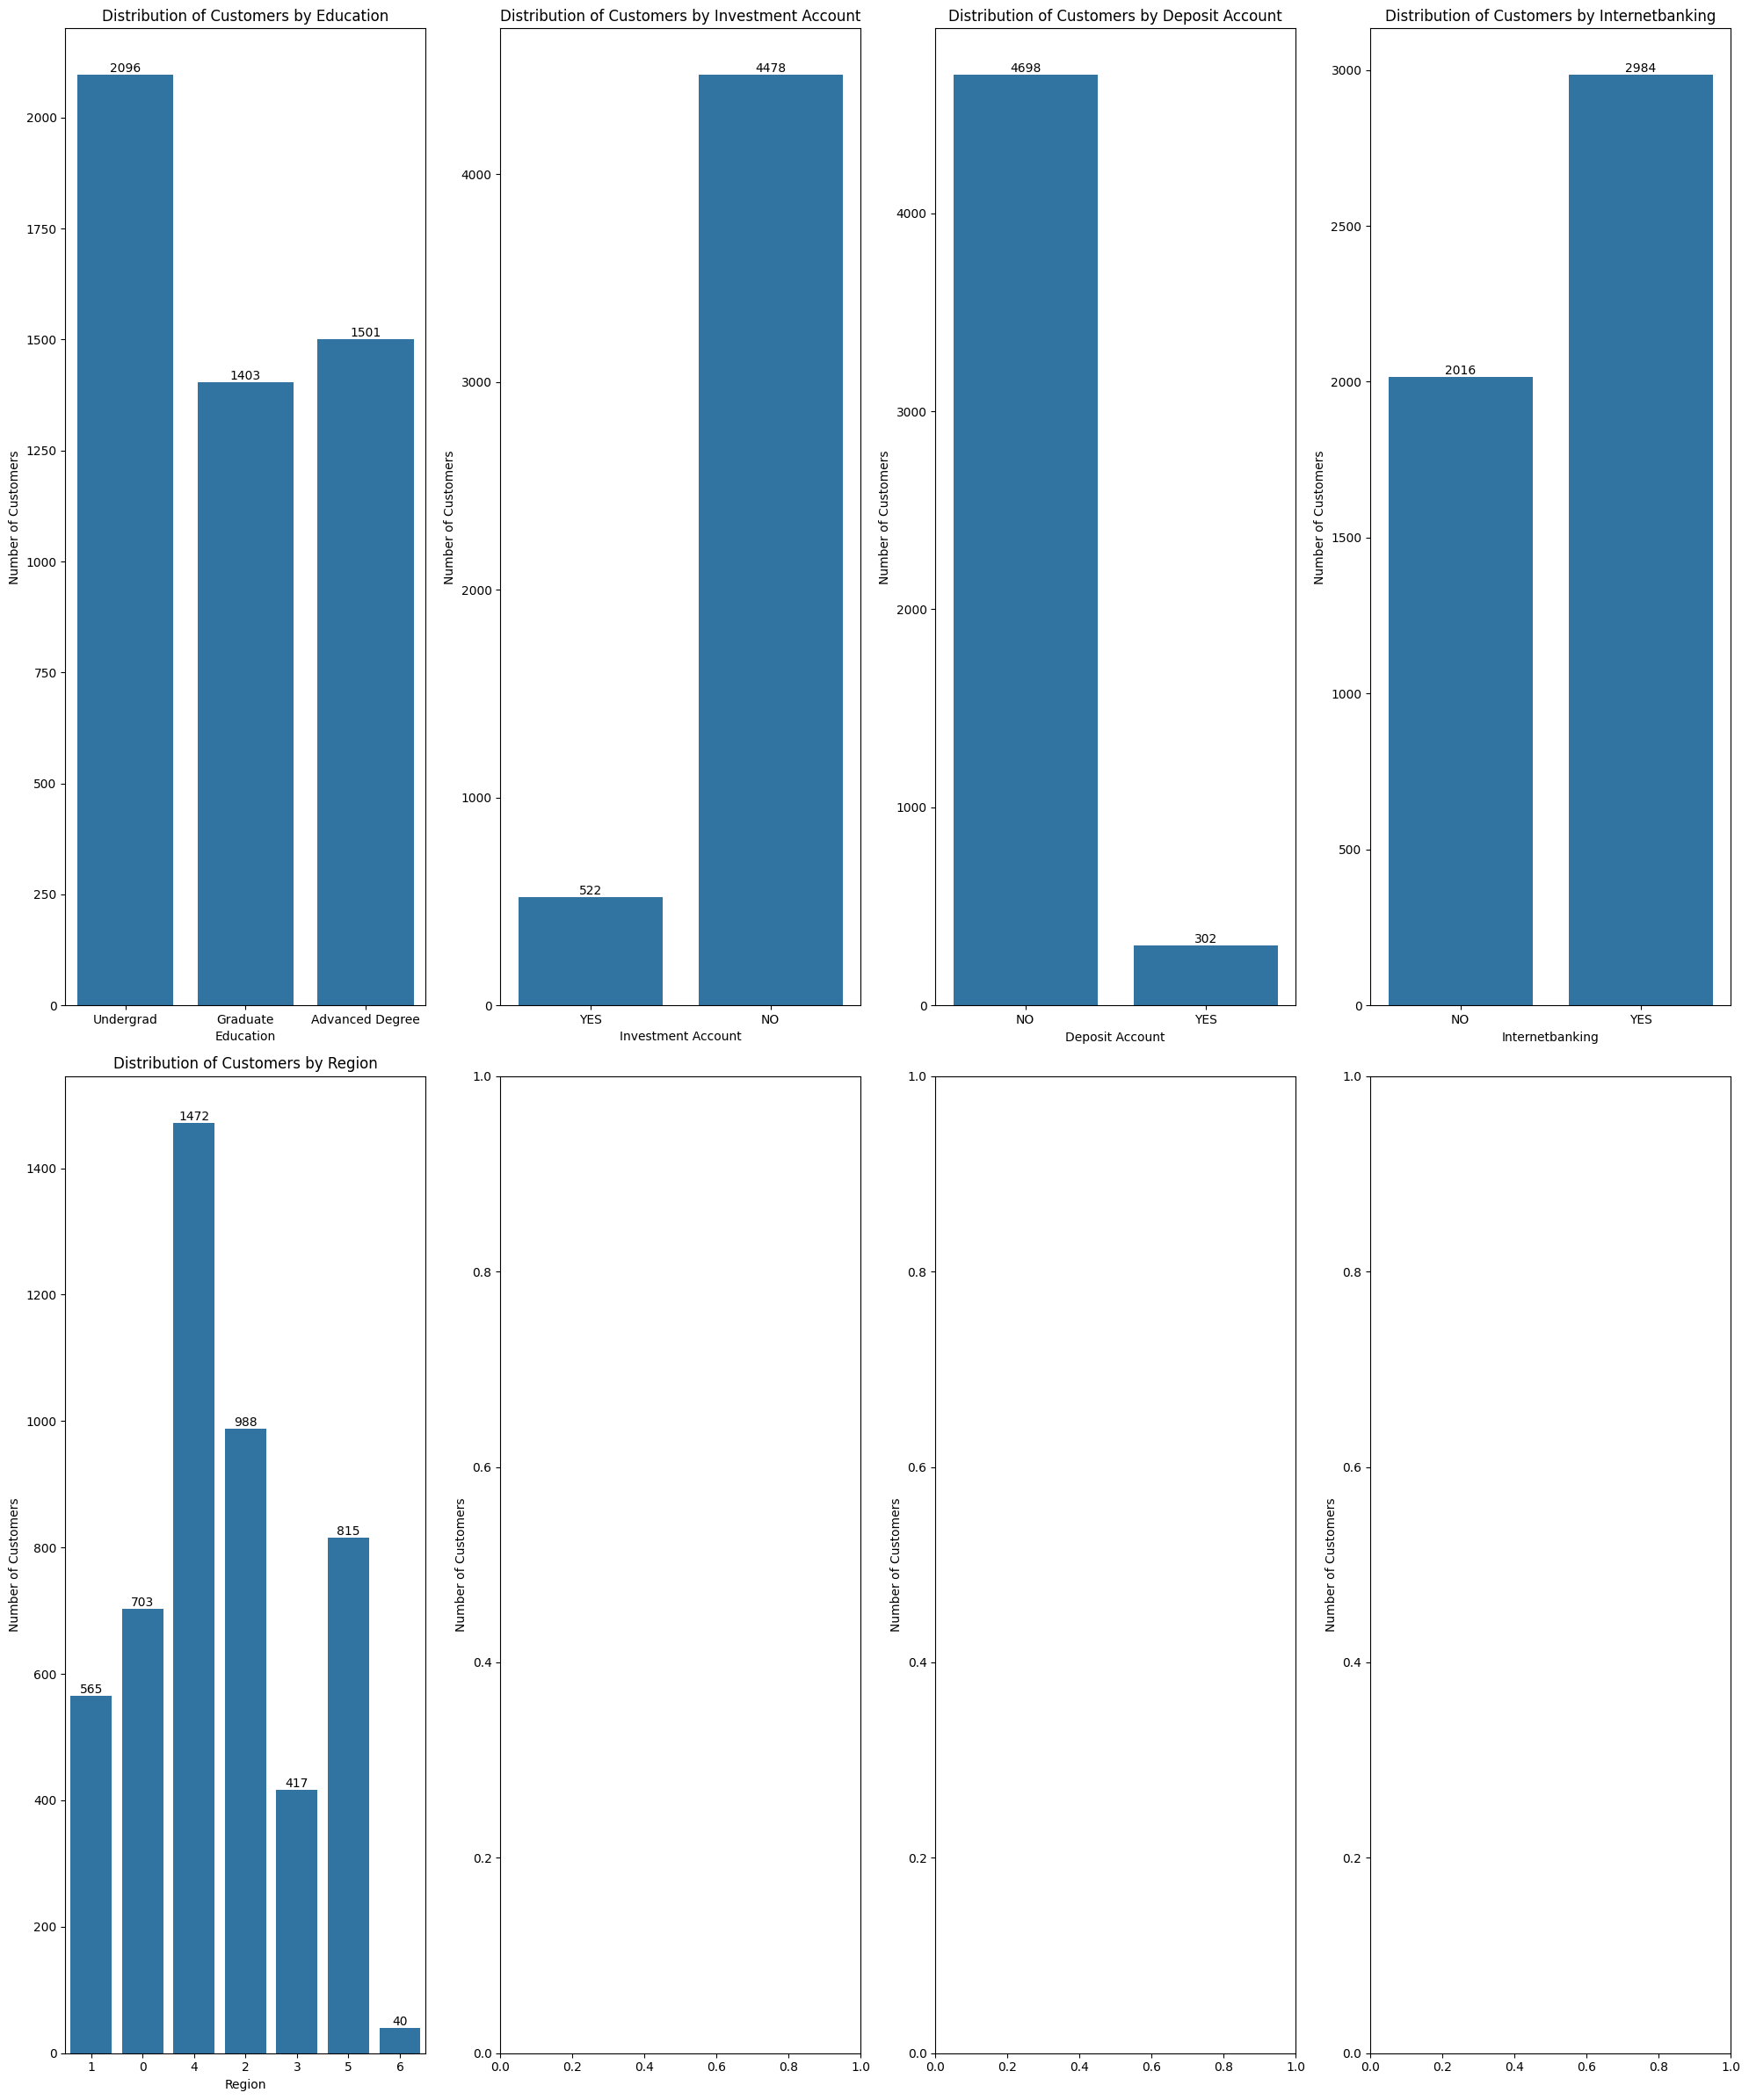

In [37]:
# Calculate the number of rows and columns needed for the subplots
n_rows = int(np.ceil(len(cat) / 4))
n_cols = 4

# Create a figure with subplots
fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 24))

# Flatten the array of subplots into a list
axs = axs.flatten()

# Create a bar chart for each categorical column
for i, col in enumerate(cat):
    ax = sns.countplot(data=base, x=col, ax=axs[i])
    ax.bar_label(ax.containers[0])

# Add a title and labels for the x and y axes
for i, ax in enumerate(axs):
    if i < len(cat):
      ax.set_title('Distribution of Customers by ' + str(cat[i].title()))
      ax.set_xlabel(cat[i].title())
    ax.set_ylabel('Number of Customers')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

In [38]:
# Generate descriptive statistics
base.describe()

,Age,Experience,Income,Family Size,CCAvgSpending,Mortgage,Personal Loan
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,45.338400,20.119600,73.545000,2.392400,1.937938,56.498800,0.096000
std,11.463166,11.440484,46.222653,1.151646,1.747659,101.713802,0.294621
min,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,0.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,101.000000,0.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,635.000000,1.000000


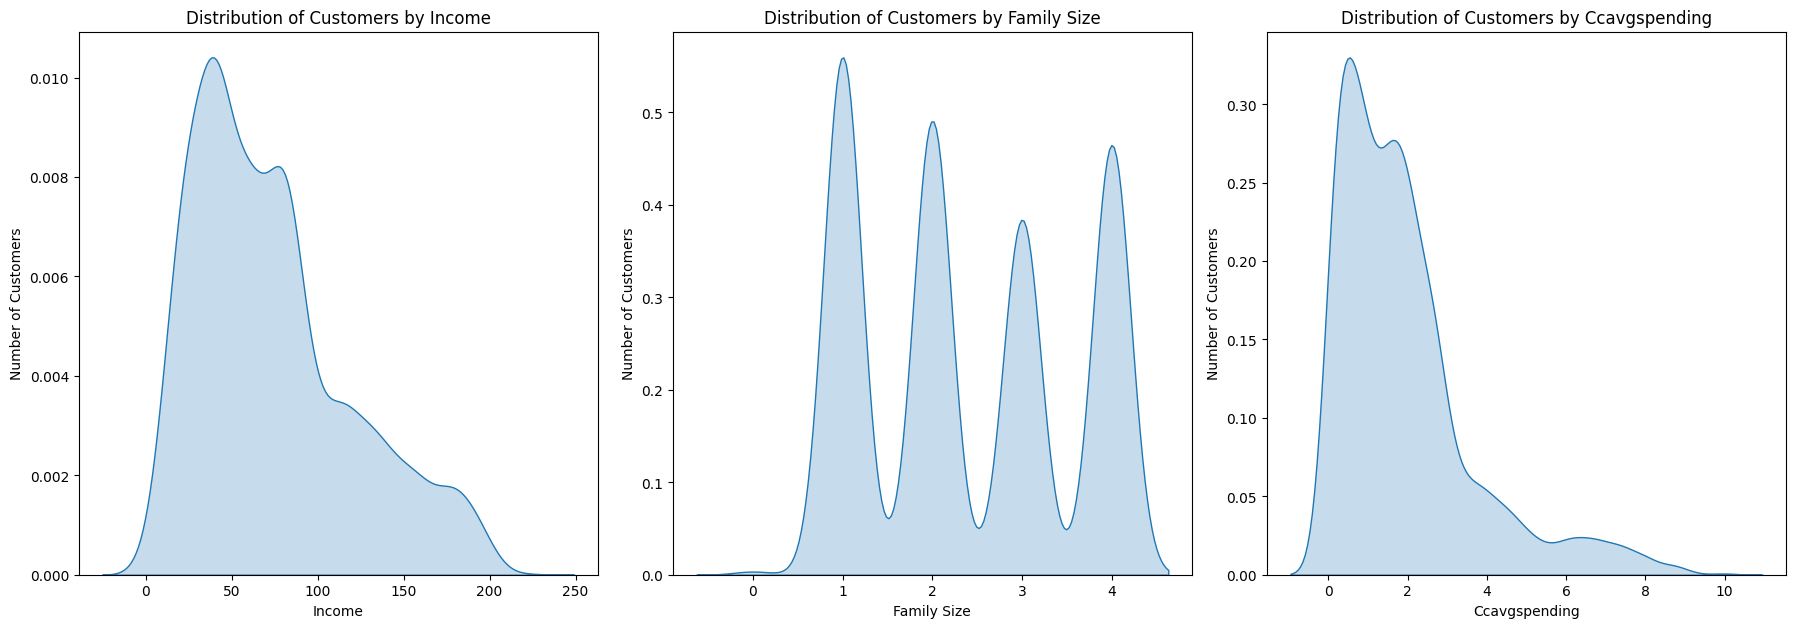

In [39]:
# Set the figure size
plt.figure(figsize=(24, 24))

# Loop over the columns and create a kde for each one
for i, col in enumerate(con):
    plt.subplot(4, 4, i+1)
    sns.kdeplot(data=base, x=col, fill=True)
    plt.title('Distribution of Customers by ' + str(con[i].title()))
    plt.xlabel(str(con[i].title()))
    plt.ylabel('Number of Customers')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

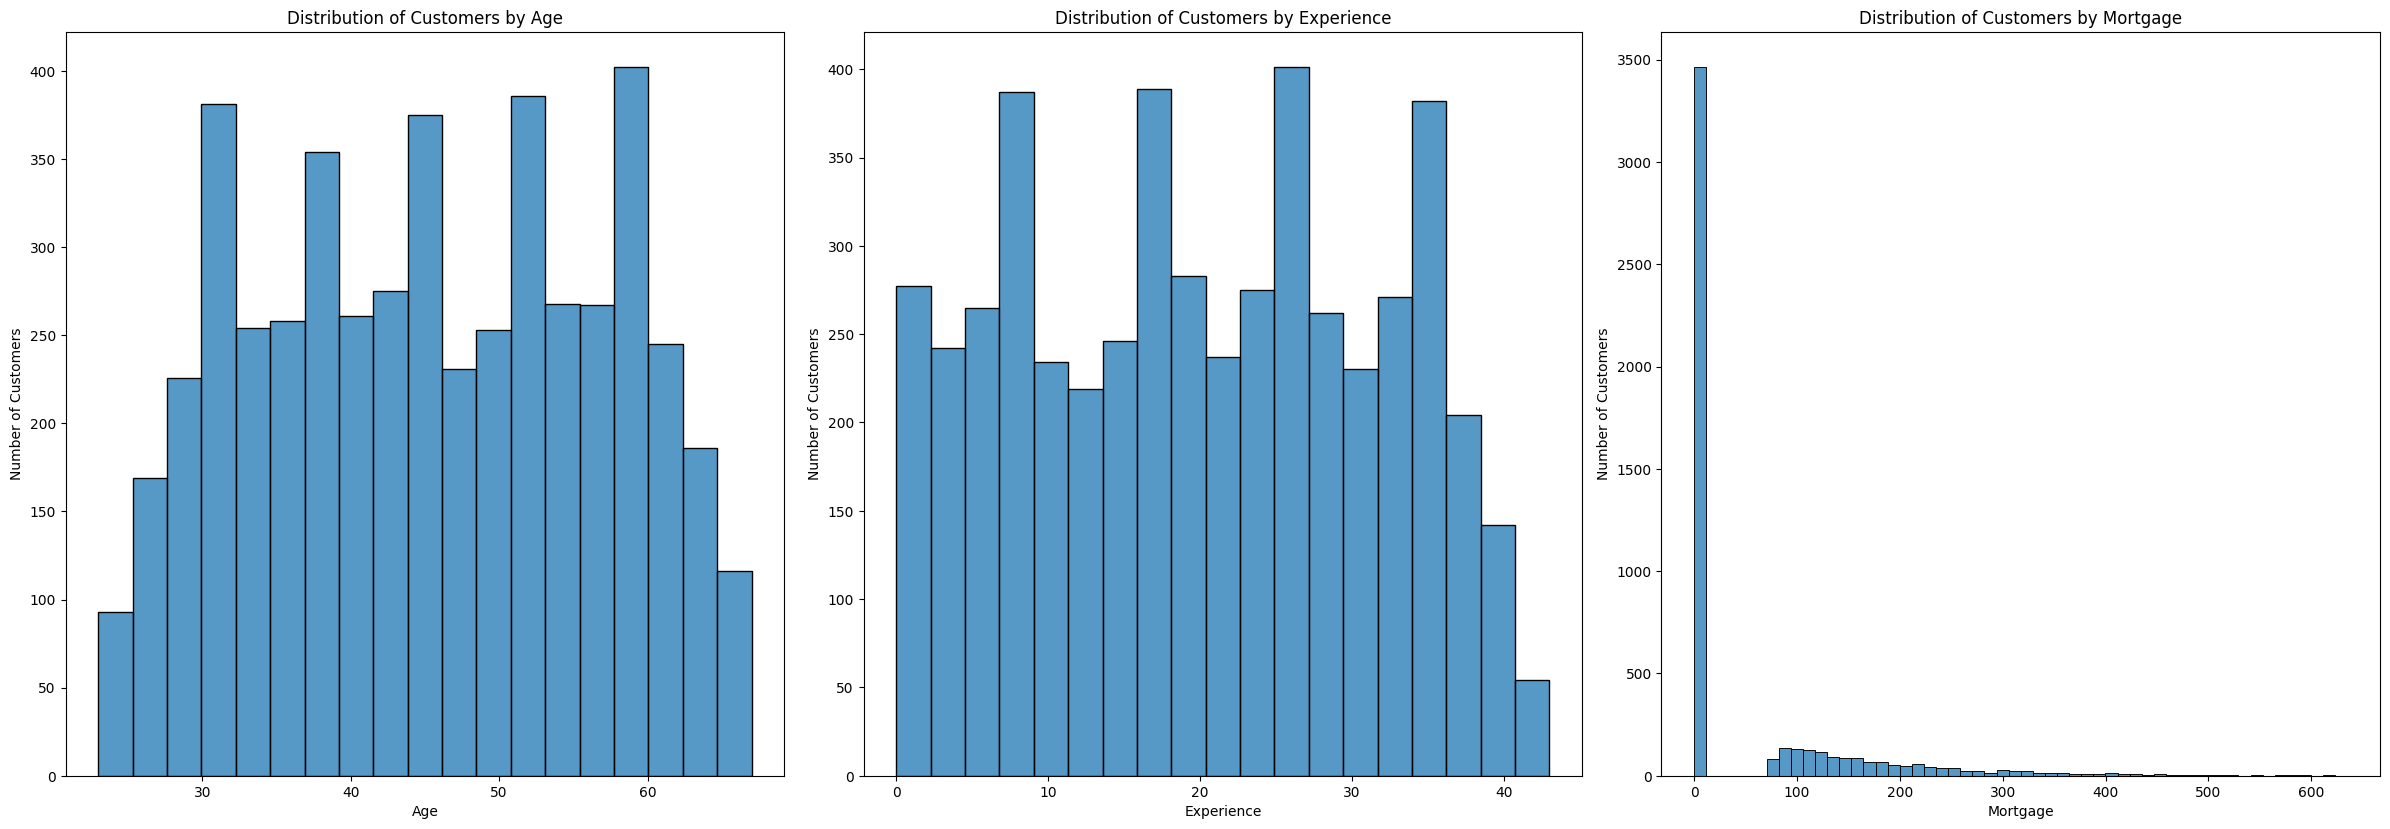

In [40]:
# Set the figure size
plt.figure(figsize=(24, 24))

# Loop over the columns and create a histogram for each one
for i, col in enumerate(dis):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=base, x=col)
    plt.title('Distribution of Customers by ' + str(dis[i].title()))
    plt.xlabel(str(dis[i].title()))
    plt.ylabel('Number of Customers')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

#### Task 3.2 : Bivariate EDA

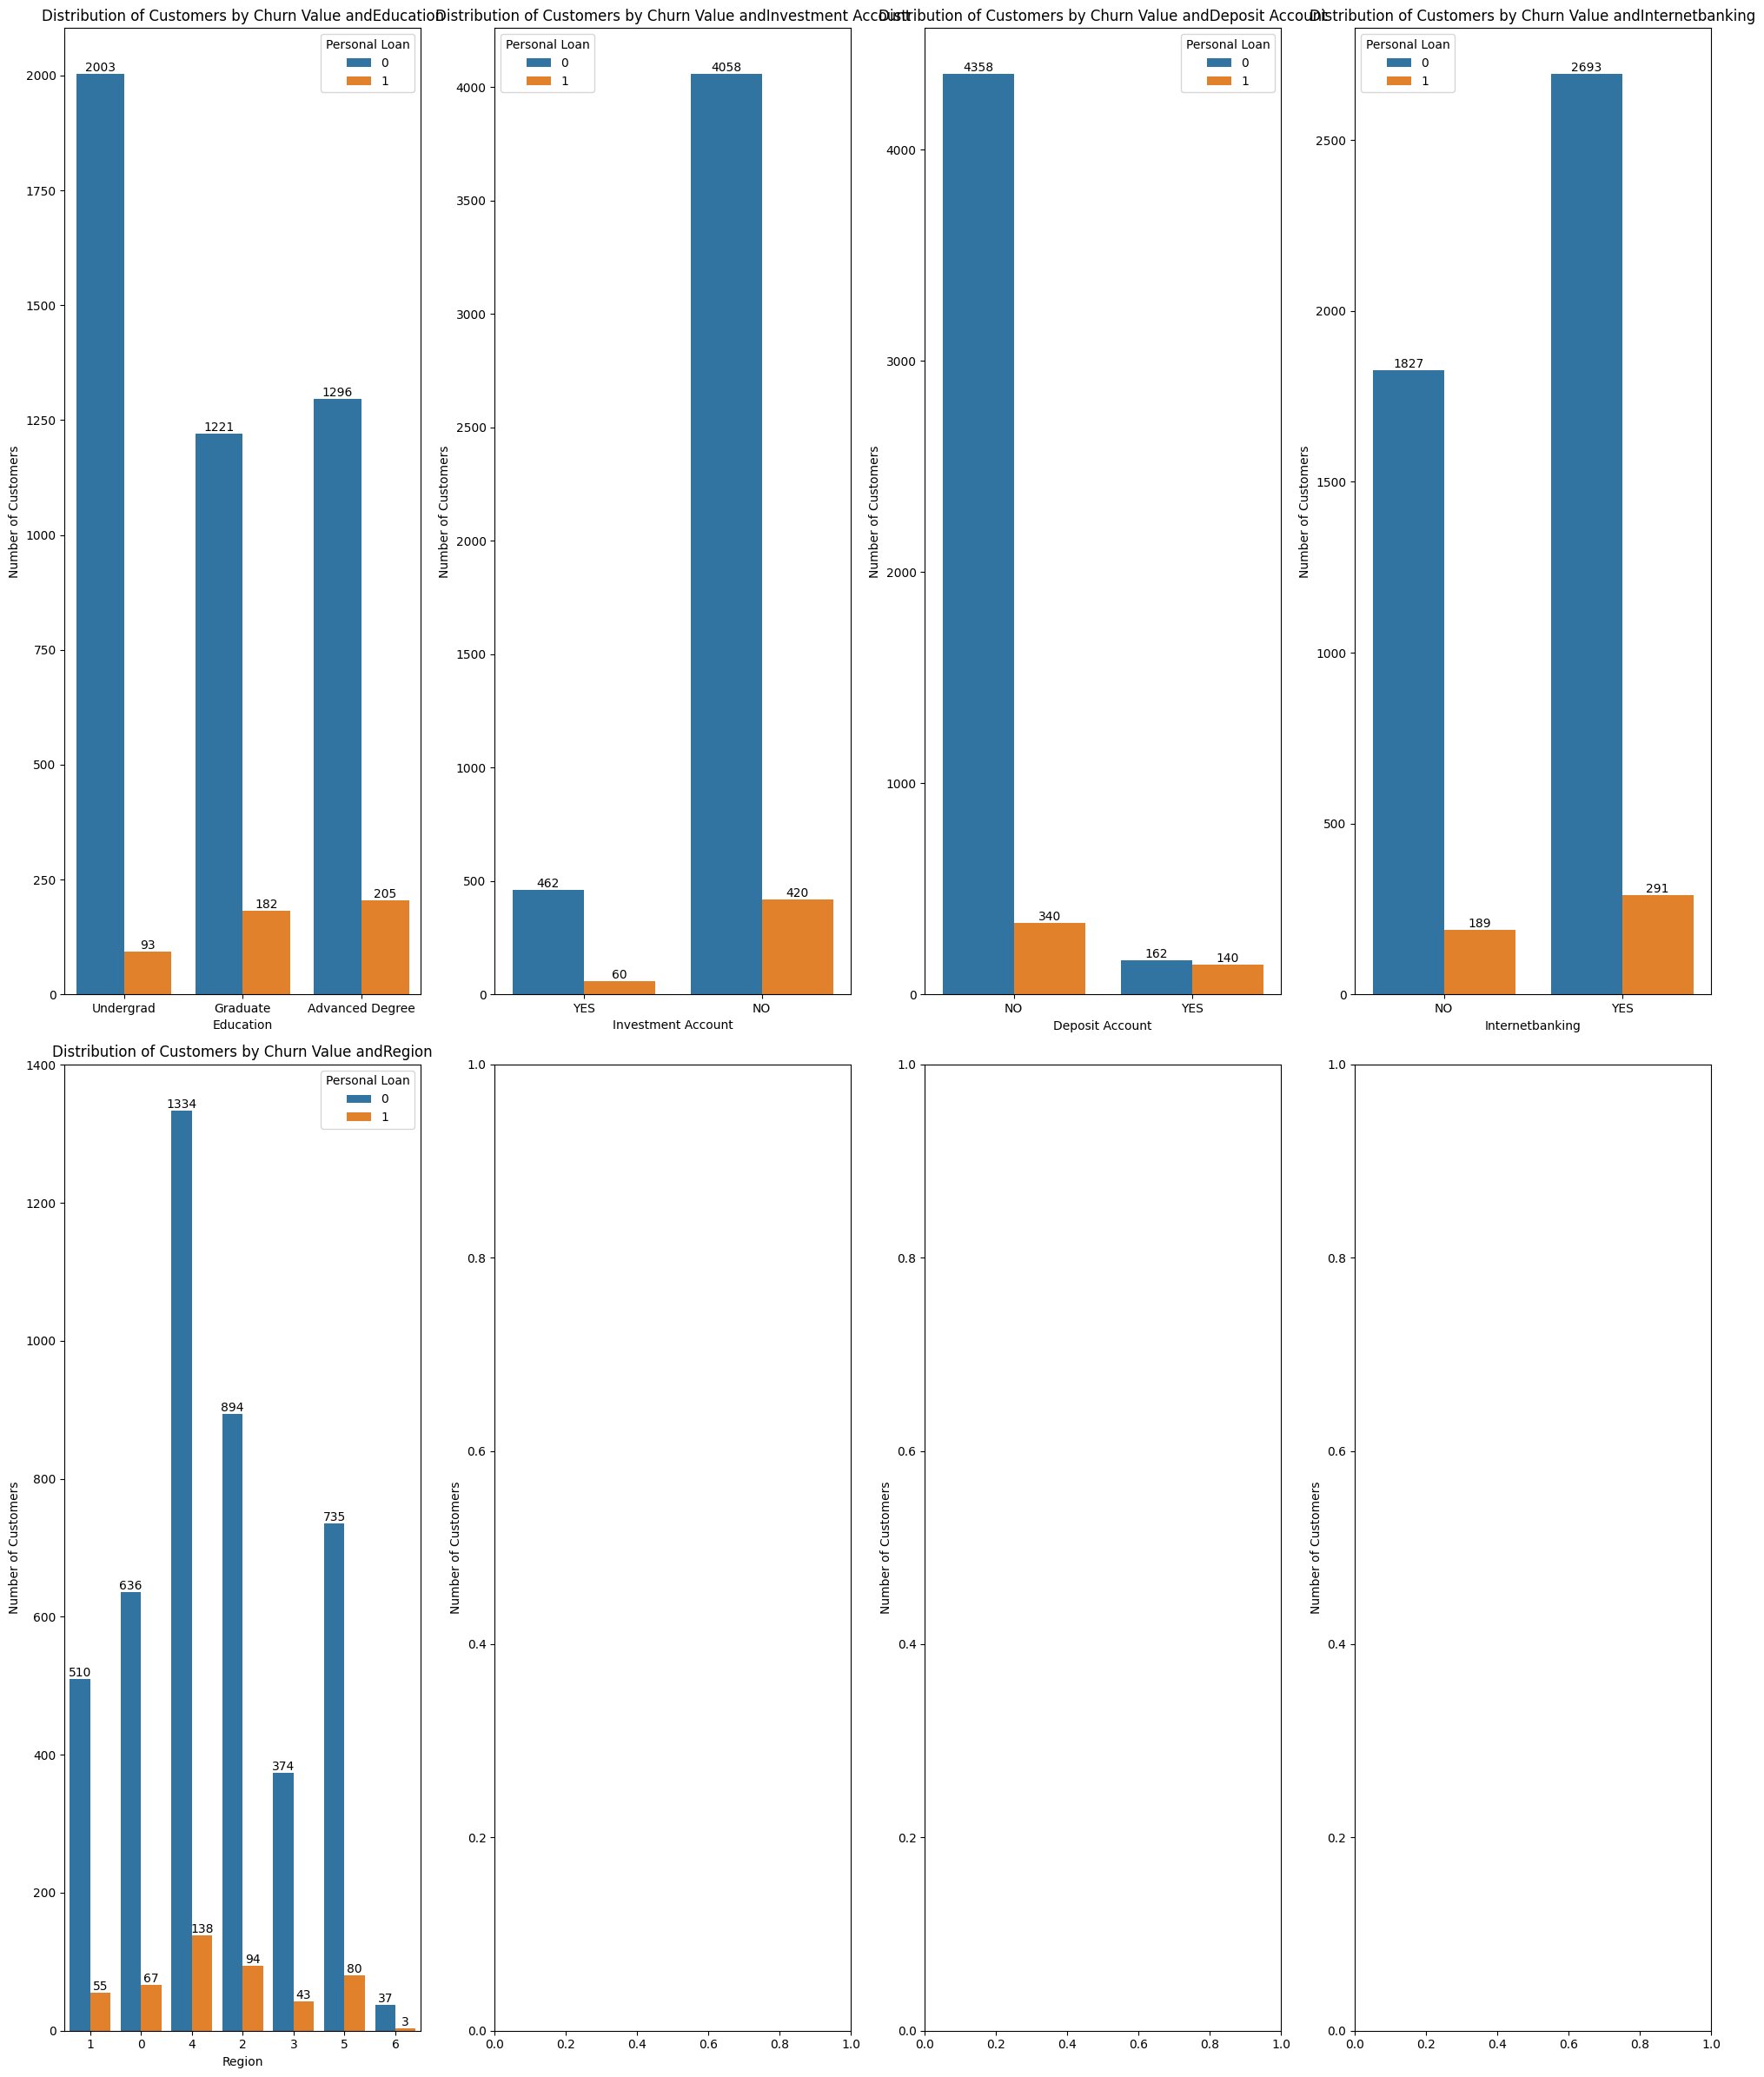

In [ ]:
# Calculate the number of rows and columns needed for the subplots
n_rows = int(np.ceil(len(cat) / 4))
n_cols = 4

# Create a figure with subplots
fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 24))

# Flatten the array of subplots into a list
axs = axs.flatten()

# Create a bar chart for each categorical column
for i, col in enumerate(cat):
    ax = sns.countplot(data=base, x=col, hue='Personal Loan', ax=axs[i])
    for i in ax.containers:
      ax.bar_label(i,)

# Add a title and labels for the x and y axes
for i, ax in enumerate(axs):
    if i < len(cat):
      ax.set_title('Distribution of Customers by Churn Value and' + str(cat[i].title()))
      ax.set_xlabel(cat[i].title())
    ax.set_ylabel('Number of Customers')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

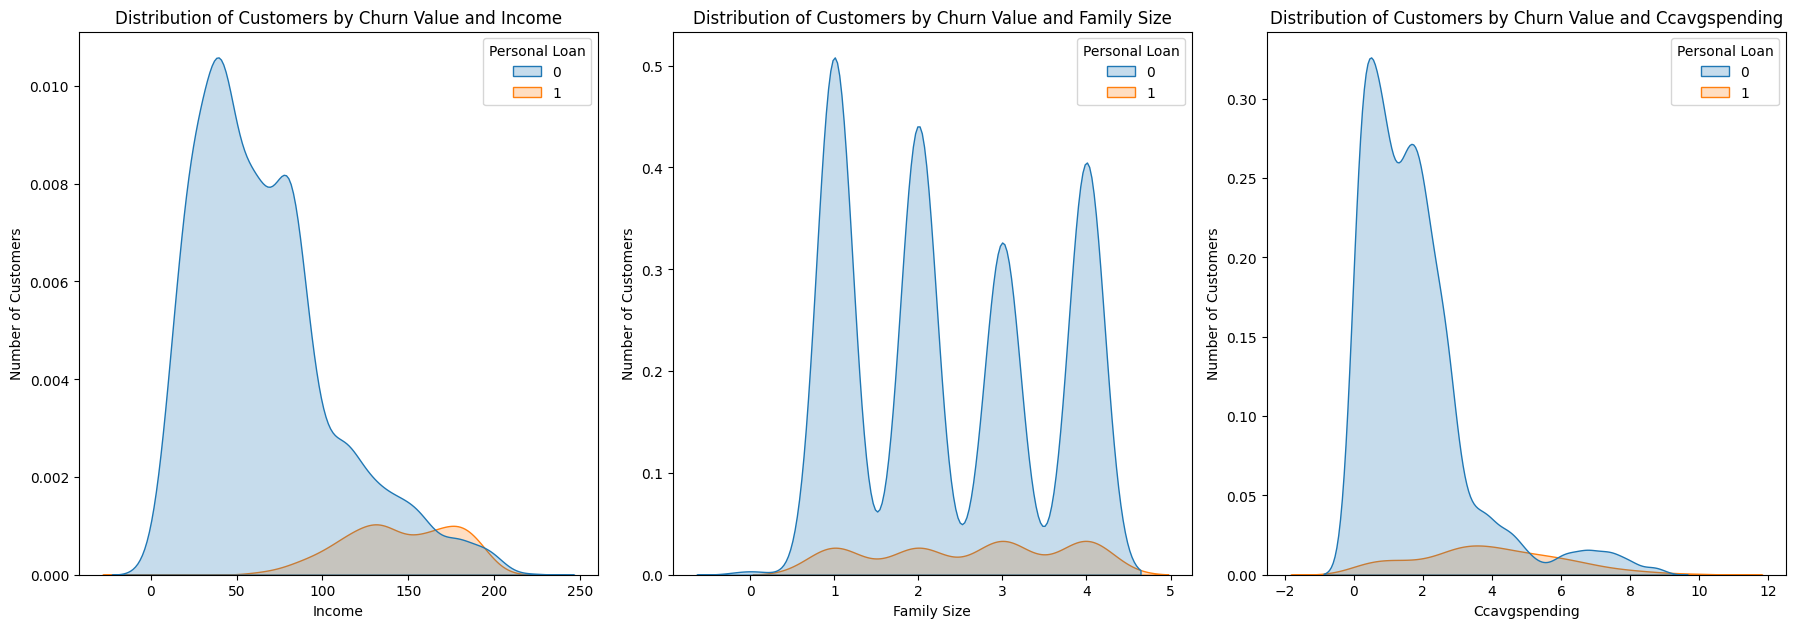

In [ ]:
# Set the figure size
plt.figure(figsize=(24, 24))

# Loop over the columns and create a kde for each one
for i, col in enumerate(con):
    plt.subplot(4, 4, i+1)
    sns.kdeplot(data=base, x=col, hue='Personal Loan', fill=True)
    plt.title('Distribution of Customers by Churn Value and ' + str(con[i].title()))
    plt.xlabel(str(con[i].title()))
    plt.ylabel('Number of Customers')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

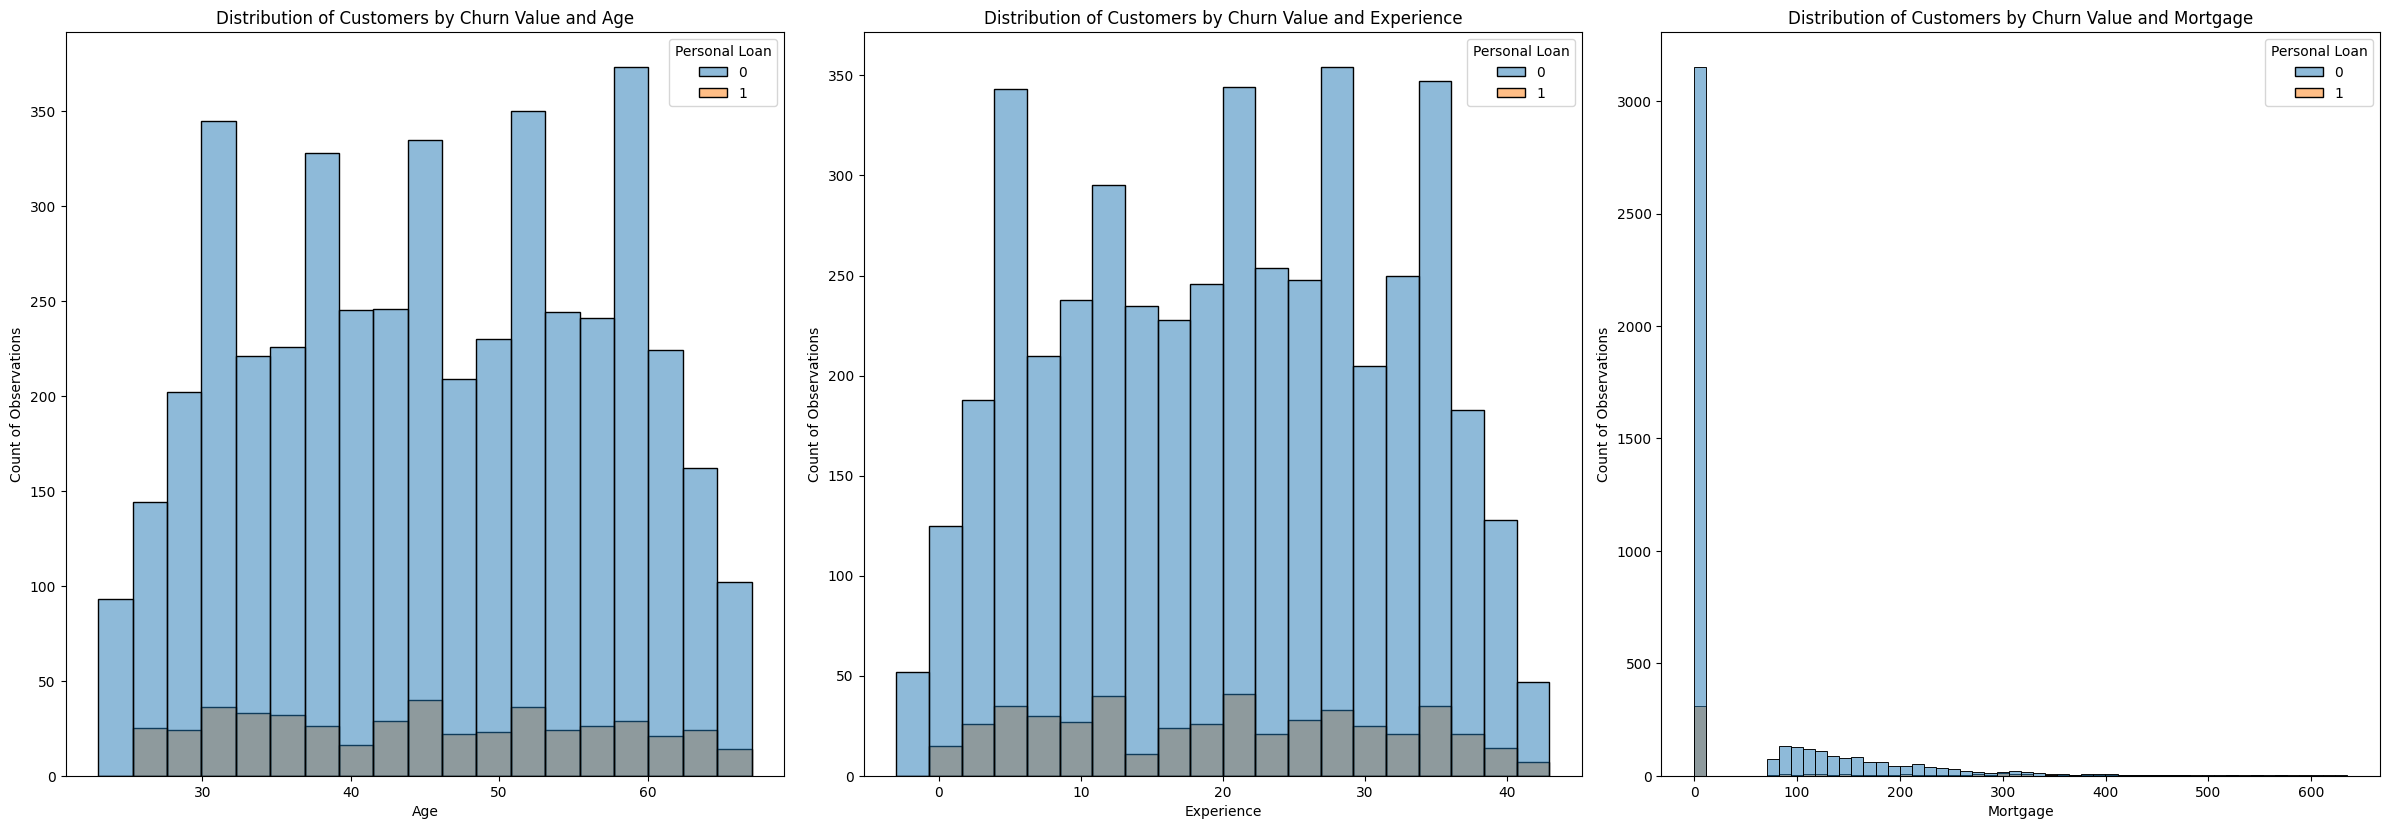

In [ ]:
# Set the figure size
plt.figure(figsize=(24, 24))

# Loop over the columns and create a histogram for each one
for i, col in enumerate(dis):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=base, x=col, hue='Personal Loan')
    plt.title('Distribution of Customers by Churn Value and ' + str(dis[i].title()))
    plt.xlabel(str(dis[i].title()))
    plt.ylabel('Count of Observations')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

**Insights from EDA**

- The highest loan participation comes from the 30–49 age bands, especially 40–49 years old.

- Customers with deposit accounts and investment accounts show lower loan take-up compared to those without.

- Customers who use Internet Banking form the majority of loan takers.

## **Task 4: Modeling**

#### Task 4.1 Modeling Technique Selection

In [41]:
# Make a copy of df's indices and data
classification = base.copy(deep=True)

In [42]:
# Separate the predictors and the labels
X = classification.drop('Personal Loan', axis=1)
y = classification['Personal Loan'].copy()

In [43]:
# Create the preprocessing pipelines for both numeric and categorical data using selectors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),  # Transform numerical columns
        ('cat', OneHotEncoder(), make_column_selector(dtype_include=object))  # Transform categorical columns
    ]
)

In [44]:
# Define the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianProcessClassifier': GaussianProcessClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [45]:
# Split the given features and the target array into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [46]:
# Train the model
def train_model(model, X_train, y_train, use_smote=False):
    if use_smote:
        pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("classifier", model)
        ])
    else:
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])

    # Measure training time and memory usage
    start_time = time.time()
    mem_usage_start = memory_usage(-1, interval=0.1, timeout=1)[0]

    # Train the classifier
    pipeline.fit(X_train, y_train)

    mem_usage_end = memory_usage(-1, interval=0.1, timeout=1)[0]
    end_time = time.time()

    training_time = end_time - start_time
    memory_used = mem_usage_end - mem_usage_start

    return pipeline, training_time, memory_used

In [47]:
# Evaluate the model
def evaluate_model(model_name, pipeline, X_train, y_train, X_test, y_test, training_time, memory_used):
    # Measure inference time and memory usage
    start_time_inference = time.time()
    mem_usage_start_inference = memory_usage(-1, interval=0.1, timeout=1)[0]

    # Make predictions on test set
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    # y_test_proba = pipeline.predict_proba(X_test)[:, 1]

    end_time_inference = time.time()
    mem_usage_end_inference = memory_usage(-1, interval=0.1, timeout=1)[0]

    inference_time = end_time_inference - start_time_inference
    memory_used_inference = mem_usage_end_inference - mem_usage_start_inference

    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    matrix = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = matrix.ravel()
    report = classification_report(y_test, y_test_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])

    # Collect results
    result = {
        "Model": model_name,
        "Train Accuracy": round(train_accuracy, 3),
        "Test Accuracy": round(test_accuracy, 3),
        "Precision_0": round(report["0"]["precision"], 3),
        "Recall_0": round(report["0"]["recall"], 3),
        "F1_0": round(report["0"]["f1-score"], 3),
        "Precision_1": round(report["1"]["precision"], 3),
        "Recall_1": round(report["1"]["recall"], 3),
        "F1_1": round(report["1"]["f1-score"], 3),
        "Overall Accuracy": round(report["accuracy"], 3),
        "True Positive": tp,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "ROC AUC": round(roc_auc, 3),
        "Training Time (s)": round(training_time, 3),
        "Memory Used (MB)": round(memory_used, 3),
        "Inference Time (s)": round(inference_time, 3),
        "Memory Used Inference (MB)": round(memory_used_inference, 3)
    }

    return result

In [48]:
# Create lists to store the results for original and SMOTE datasets
results_list_original = []

# Train and evaluate each classifier on both the original and SMOTE-balanced datasets
for name, clf in classifiers.items():
    # Train the model
    pipeline_original, training_time_original, memory_used_original = train_model(clf, X_train, y_train, use_smote=False)

    # Evaluate the model
    result_original = evaluate_model(name, pipeline_original, X_train, y_train, X_test, y_test, training_time_original, memory_used_original)

    # Append results to the respective lists
    results_list_original.append(result_original)

# Convert results to DataFrames
results_df_original = pd.DataFrame(results_list_original)


In [49]:
# Display results
results_df_original

,Model,Train Accuracy,Test Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Overall Accuracy,True Positive,True Negative,False Positive,False Negative,ROC AUC,Training Time (s),Memory Used (MB),Inference Time (s),Memory Used Inference (MB)
0,Logistic Regression,0.957,0.960,0.969,0.988,0.978,0.859,0.698,0.770,0.960,67,893,11,29,0.960,2.069,0.625,1.022,0.000
1,KNeighborsClassifier,0.969,0.954,0.954,0.997,0.975,0.946,0.552,0.697,0.954,53,901,3,43,0.929,2.024,0.000,1.187,0.500
2,GaussianProcessClassifier,0.984,0.965,0.964,0.999,0.981,0.984,0.646,0.780,0.965,62,903,1,34,0.982,31.861,132.281,1.693,0.078
3,GaussianNB,0.896,0.886,0.947,0.926,0.936,0.422,0.510,0.462,0.886,49,837,67,47,0.916,2.026,0.000,1.023,0.000
4,Decision Tree,1.000,0.984,0.996,0.987,0.991,0.885,0.958,0.920,0.984,92,892,12,4,0.973,2.031,0.125,1.031,0.000
5,Random Forest,1.000,0.989,0.993,0.994,0.994,0.947,0.938,0.942,0.989,90,899,5,6,0.998,2.426,0.125,1.074,0.000


***Hyperparameter Tuning to increase the AUC**

In [50]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
    'classifier__max_iter': [100, 200, 500, 1000]
}

# Create a pipeline for Logistic Regression with hyperparameter tuning
pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=pipeline_lr, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Train the model with Grid Search
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
700 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7bf4fe75a420>),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7bf4fe72a7e0>)])),
                                       ('classifier',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__max_iter': [100, 200, 500, 1000],
                         'classifier__penalty': ['l1', 'l2', 'elasticnet',
                                                 'none'],
                         'classifier__solver': ['lbfgs', 'liblinear', 'saga']},
             scoring='roc_auc')

In [51]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

Best Parameters: {'classifier__C': 0.1, 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best Cross-Validation Score: 0.9584300835367741


In [52]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test)

result_best_model = evaluate_model("Best Logistic Regression Model", best_model, X_train, y_train, X_test, y_test, 0, 0)  # Training time and memory usage are not relevant here
result_best_model

{'Model': 'Best Logistic Regression Model',
 'Train Accuracy': 0.953,
 'Test Accuracy': 0.959,
 'Precision_0': 0.962,
 'Recall_0': 0.993,
 'F1_0': 0.978,
 'Precision_1': 0.91,
 'Recall_1': 0.635,
 'F1_1': 0.748,
 'Overall Accuracy': 0.959,
 'True Positive': np.int64(61),
 'True Negative': np.int64(898),
 'False Positive': np.int64(6),
 'False Negative': np.int64(35),
 'ROC AUC': np.float64(0.963),
 'Training Time (s)': 0,
 'Memory Used (MB)': 0,
 'Inference Time (s)': 1.022,
 'Memory Used Inference (MB)': 0.0}

In [57]:
with open(base_dir + 'preprocessor_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save best model with pickle
with open(base_dir + 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

**Repeat for Random Forest**

In [54]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}

# Create a pipeline with Random Forest
pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Perform Grid Search with cross-validation using ROC AUC
grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',   # <-- scoring changed to ROC AUC
    n_jobs=-1
)

# Train the model with Grid Search
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7bf4fe75a420>),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7bf4fe72a7e0>)])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20, 30],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 500]},
             scoring='roc_auc')

In [55]:
# Get the best parameters and best score
RF_best_params = grid_search.best_params_
RF_best_score = grid_search.best_score_

print("Best Parameters:", RF_best_params)
print("Best Cross-Validation Score:", RF_best_score)

Best Parameters: {'classifier__max_depth': None, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}
Best Cross-Validation Score: 0.9971875973168581


In [56]:
# Evaluate the best model on the test set
RF_best_model = grid_search.best_estimator_

y_test_pred = RF_best_model.predict(X_test)

RF_result_best_model = evaluate_model("Best Logistic Regression Model", RF_best_model, X_train, y_train, X_test, y_test, 0, 0)  # Training time and memory usage are not relevant here
RF_result_best_model

{'Model': 'Best Logistic Regression Model',
 'Train Accuracy': 1.0,
 'Test Accuracy': 0.988,
 'Precision_0': 0.994,
 'Recall_0': 0.992,
 'F1_0': 0.993,
 'Precision_1': 0.929,
 'Recall_1': 0.948,
 'F1_1': 0.938,
 'Overall Accuracy': 0.988,
 'True Positive': np.int64(91),
 'True Negative': np.int64(897),
 'False Positive': np.int64(7),
 'False Negative': np.int64(5),
 'ROC AUC': np.float64(0.999),
 'Training Time (s)': 0,
 'Memory Used (MB)': 0,
 'Inference Time (s)': 1.183,
 'Memory Used Inference (MB)': 0.0}

In [58]:
with open(base_dir + 'rf_preprocessor_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save best model with pickle
with open(base_dir + 'rf_best_model.pkl', 'wb') as f:
    pickle.dump(RF_best_model, f)